<a href="https://colab.research.google.com/github/eitt/farm_models/blob/main/%5B2025_2%5D_Farm_Models_EU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline explanation (Version 3.1) — Entropy (weights) + Min–Max (scores) + Optimized Clustering

Dear Stamatis,

This is the end-to-end description matching the **final implemented version (3.1)**, including static figure optimization and title removal:

* **Orientation**: COST → −X (no shift).
* **Entropy weights**: from **column-sum probabilities** of the oriented matrix.
* **Dimension scores**: **0–1 min–max** per indicator (after orientation), then weighted by Shannon weights.
* **Clustering add-on**: reuses already computed matrices (no re-normalization).



## 🟦 Inputs

### Files & paths

* `FILE` → `/content/data.xlsx` (Excel with **3 sheets**: *Economic*, *Environmental*, *Social*)
* `OUT`  → `/content/` (output folder)

### Data specifications

* `SCHEMA` lists the exact indicator columns per sheet.
* First column is **COUNTRY** (labels); remaining columns are **numeric**.
* `COST_COLUMNS` flags indicators where **higher = worse** (COST); all others are **BENEFIT** (higher = better).
* `EU27` country labels like `"(AT) Austria"` are used for subset analysis.



## 🟩 Outputs

### One workbook

`/content/Entropy_Pipeline_Outputs.xlsx` with sheets:

* **README** – short description of each sheet.
* **Data** – raw numeric indicators.
* **Oriented** – oriented indicators (BENEFIT: `+X`, COST: `−X`).
* **Probabilities** – entropy probabilities $P$ (column-wise proportions from **oriented** data; used only to compute entropy).
* **Entropy\_Weights** – $\{w_j\}$ per indicator (by dimension), from $P$.
* **Norm01** – **0–1 min–max** of oriented indicators (per column).
* **Scores\_Wide** – per-country **Economic / Environmental / Social** scores based on **Norm01** and $\{w_j\}$.
* **Sankey\_Links** – edges (Indicator → Dimension, value = weight).
* **EU\_SD\_Classes** – EU-only scores with $\mu\pm\sigma$ class labels.
* **EU\_SD\_Stats** – $\mu$ and $\sigma$ per dimension (EU subset).

### Plots (Optimized: JPG/300 DPI/A4 width; **No Titles on Figures**)

| Type | Content | File Name Convention |
| : | : | : |
| **Static Sankey** | Entropy flow (Indicator → Dimension). | `Sankey_{Dimension}_Static.jpg` |
| **Bar Chart** | 3 panels of EU scores colored by $\mu\pm\sigma$ class. | `EU_Bar_Chart.jpg` |
| **Scatter** | 2x2 grid (3 pairwise score plots + 1 corner legend). | `EU_Scatter_2x2_Optimized.jpg` |
| **Dendrogram** | Hierarchical clustering cut, marked by $k_{opt}$. | `Dendrogram_Ward_Cut_k{k_opt}.png` |
| **Metrics** | 6 plots of validity metrics vs. $k$ (e.g., Silhouette, Gap). | `Cluster_Validity_Summary_k{k_opt}.png` |
| **Scatter (Clusters)**| 2x2 grid of pairwise score plots colored by cluster. | `Scatter_Dimension_Scores_k{k_opt}.png` |

**Clustering Audit Trail**

* `Clusters_Assignments.csv` (COUNTRY → Cluster)
* `Clustering_Features_Weighted.csv` (audit trail: exact feature matrix $X_w$ used for clustering)



## 1) Per-sheet setup (Economic / Environmental / Social)

Let $X=[x_{ij}]$ be the raw matrix (countries $i=1,\dots,n$; indicators $j=1,\dots,m$).



## 2) Orientation (no shift)

Apply **only** the sign flip for COST:

$$
x^{*}_{ij}=
\begin{cases}
x_{ij}, & \text{BENEFIT}\\
-\,x_{ij}, & \text{COST}
\end{cases}
$$

* **Oriented Matrix**: $X^*=[x^{*}_{ij}]$ (stored in sheet **Oriented**).



## 3) Column-sum probabilities (Shannon inputs)

The probability matrix $P=[p_{ij}]$ is calculated by column-wise $L_1$ normalization on $X^*$:

$$
p_{ij}=
\begin{cases}
\dfrac{x^{*}_{ij}}{S^{*}_j}, & S^{*}_j\neq 0\\[6pt]
0, & S^{*}_j=0
\end{cases}
\qquad\text{where } S^{*}_j=\sum_i x^{*}_{ij} .
$$

* $P$ is stored in sheet **Probabilities**. This works because the sign flip ensures $p_{ij}\ge 0$ for COST columns.



## 4) Shannon entropy & weights (per indicator, per dimension)

Entropy $e_j$ and diversification $d_j$ are calculated:

$$
e_j = -\,k \sum_{i=1}^n p_{ij}\,\ln p_{ij} \quad \left(k=\dfrac{1}{\ln n}\right), \qquad
d_j = 1-e_j.
$$

The final normalized entropy weight $w_j$ is:

$$
w_j = \frac{d_j}{\sum_{t=1}^{m} d_t}.
$$

* $\{w_j\}$ are stored in sheet **Entropy\_Weights**.



## 5) Per-indicator 0–1 min–max (after orientation)

The oriented matrix $X^*$ is scaled per-column to the range $[0,1]$:

$$
\bar{x}_{ij} \;=\;
\frac{x^{*}_{ij} - \min_i x^{*}_{ij}}{\max_i x^{*}_{ij} - \min_i x^{*}_{ij}}\;\in[0,1].
$$

* The $\mathbf{0–1}$ matrix $\bar{X}=[\bar{x}_{ij}]$ is stored in sheet **Norm01**.



## 6) Per-country dimension score (min–max based)

The score is a weighted sum of the $\mathbf{0–1}$ normalized indicators $\bar{x}_{ij}$ using the entropy weights $w_j$:

$$
\text{Score}_i^{(\text{dimension})}
= \sum_{j=1}^m w_j\,\bar{x}_{ij}.
$$

* Scores are stored in sheet **Scores\_Wide**.



## 7) EU $\mu\pm\sigma$ classification & plots

Scores for the **EU subset** are classified into four bands based on the EU mean ($\mu$) and standard deviation ($\sigma$):

* **Sustainable:** $x>\mu+\sigma$
* **Relatively Sustainable:** $\mu < x \le \mu+\sigma$
* **Relatively Unsustainable:** $\mu-\sigma < x \le \mu$
* **Unsustainable:** $x \le \mu-\sigma$

These classes are used to color the horizontal bars and the points in the pairwise scatterplots.



## 8) Hierarchical clustering (add-on: default feature space)

The default approach keeps clustering on the **distributional view** ($P$) weighted by $w$ to ensure consistency with the entropy calculation, while enforcing equal influence ($1/3$) across the three dimensions.

$$
\text{Feature Matrix } X_w = \text{Concatenate}_{d} \left\{ \tilde{P}^{(d)}_{ij} \right\}
\quad\text{where } \quad
\tilde{P}^{(d)}_{ij}= \sqrt{\tfrac{w^{(d)}_j}{3}}\; P^{(d)}_{ij}
$$

* **Method:** Ward's linkage on Euclidean distance.
* **Optimal $k$:** Chosen using Gap Statistic (1-SE rule), Silhouette, and Calinski–Harabasz.
* **Output:** Dendrogram cut is fixed at the optimal $k$ ($k_{opt}$) and cluster assignments are saved.

In [ ]:
!pip install xlsxwriter

In [ ]:
# ============================================
# ENTROPY PIPELINE (Version 3.5 - Legend in Empty Quadrant)
# - Static Sankeys
# - 2x2 Scatter Grid: External Labels & Legend in 4th Quadrant
# - Tier Names: High, Medium-high, Medium-low, Low
# ============================================
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.path as mpath

# ---------- CONFIG ----------
FILE = "/content/data.xlsx"      # Input Excel File
OUT  = "/content/"               # Output Folder
XLSX_OUT = os.path.join(OUT, "Entropy_Pipeline_Outputs.xlsx")

# A4 Specifications
A4_WIDTH_INCHES = 8.27
DPI_SETTING = 300

# Schema definition
SCHEMA = {
    "Economic": [
        "Net Farm Income ratio",
        "Efficiency",
        "Labour Productivity",
        "Total subsidies/Farm Family Income",
        "Capital Productivity",
    ],
    "Environmental": [
        "Share of UAA for organic farming",
        "Livestock density (Livestock Units/Ha)",
        "Fertilizer usage (Kg/Ha)",
        "Pesticide usage (Kg/Ha)",
        "Energy Intensity (Fuel consumption in liters/Ha)",
        "Water Intensity (Water consumption in m^3/Ha)",
    ],
    "Social": [
        "Family Farm Income/Reference Income",
        "Family Work Unit/Total labour",
        "Other gainful activities/Total output",
        "Structural change rate",
        "Farm use/Total inputs",
    ],
}

# Cost columns (Negative impact)
COST_COLUMNS = {
    "Economic": ["Total subsidies/Farm Family Income"],
    "Environmental": [
        "Livestock density (Livestock Units/Ha)",
        "Fertilizer usage (Kg/Ha)",
        "Pesticide usage (Kg/Ha)",
        "Energy Intensity (Fuel consumption in liters/Ha)",
        "Water Intensity (Water consumption in m^3/Ha)",
    ],
    "Social": ["Structural change rate"]
}

EU27 = {
    "(AT) Austria","(BE) Belgium","(BG) Bulgaria","(HR) Croatia","(CY) Cyprus","(CZ) Czechia",
    "(DK) Denmark","(EE) Estonia","(FI) Finland","(FR) France","(DE) Germany","(EL) Greece",
    "(HU) Hungary","(IE) Ireland","(IT) Italy","(LV) Latvia","(LT) Lithuania","(LU) Luxembourg",
    "(MT) Malta","(NL) Netherlands","(PL) Poland","(PT) Portugal","(RO) Romania",
    "(SK) Slovakia","(SI) Slovenia","(ES) Spain","(SE) Sweden"
}

# ---------- HELPERS: DATA PROCESSING ----------
def orient_only(raw_df: pd.DataFrame, cost_set: set) -> pd.DataFrame:
    X = raw_df.astype(float).copy()
    for c in X.columns:
        if c in cost_set:
            X[c] = -X[c]
    return X

def minmax01_by_column(X_oriented: pd.DataFrame) -> pd.DataFrame:
    X = X_oriented.astype(float)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    ranges = (maxs - mins)
    Z = (X - mins) / ranges.replace(0.0, np.nan)
    Z = Z.fillna(0.0)
    return Z.clip(lower=0.0, upper=1.0)

def compute_probabilities(X_oriented: pd.DataFrame) -> pd.DataFrame:
    X = X_oriented.astype(float)
    col_sums = X.sum(axis=0)
    P = X.div(col_sums.where(col_sums != 0, np.nan), axis=1)
    P = P.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    P = P.clip(lower=0.0).abs()
    return P

def entropy_weights_from_probs(P: pd.DataFrame) -> pd.Series:
    col_sums = P.sum(axis=0)
    valid = col_sums[col_sums > 0].index
    if len(valid) == 0:
        return pd.Series(1.0 / P.shape[1], index=P.columns)

    n = P.shape[0]
    k = 1.0 / math.log(n) if n > 1 else 0.0
    with np.errstate(divide='ignore', invalid='ignore'):
        logP = np.log(P[valid].replace(0, np.nan))
    term = (P[valid] * logP).fillna(0.0)

    e = -k * term.sum(axis=0)
    d = 1.0 - e
    w_valid = (d / d.sum()) if d.sum() > 0 else pd.Series(1.0/len(valid), index=valid)

    w = pd.Series(0.0, index=P.columns, dtype=float)
    w.loc[w_valid.index] = w_valid
    return (w / w.sum()) if w.sum() > 0 else pd.Series(1.0/len(w), index=w.index)

def process_sheet(df: pd.DataFrame, sheet_name: str):
    country_col = df.columns[0]
    countries = df[country_col].astype(str).str.strip()
    cols = SCHEMA[sheet_name]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"[{sheet_name}] Missing columns: {missing}")

    raw = df[cols].astype(float)
    cost_set = set(COST_COLUMNS.get(sheet_name, []))
    oriented = orient_only(raw, cost_set)
    print(oriented)
    P = compute_probabilities(oriented)
    w = entropy_weights_from_probs(P)
    norm01 = minmax01_by_column(oriented)
    score = (norm01 * w).sum(axis=1)

    return {
        "countries": countries,
        "raw": raw,
        "oriented": oriented,
        "P": P,
        "norm01": norm01,
        "weights": w,
        "score": score,
        "cols": cols
    }

# ---------- HELPERS: GRAPHICS (SANKEY) ----------
def draw_static_sankey_matplotlib(sheet_name, weights, filename_out):
    indicators = list(SCHEMA[sheet_name])
    vals = [float(weights[ind]) for ind in indicators]
    total_weight = sum(vals)

    fig, ax = plt.subplots(figsize=(A4_WIDTH_INCHES, A4_WIDTH_INCHES * 0.6))
    ax.axis('off')

    left_x, right_x = 0.05, 0.95
    width_gap = right_x - left_x
    y_top, y_bottom = 0.9, 0.1
    h_avail = y_top - y_bottom

    r_height = h_avail
    r_center_y = (y_top + y_bottom) / 2
    r_bottom_y = y_bottom

    # Right Box
    ax.add_patch(mpatches.FancyBboxPatch(
        (right_x - 0.02, r_bottom_y), 0.04, r_height,
        boxstyle="round,pad=0.01", ec="black", fc="#444444", lw=1
    ))
    ax.text(right_x + 0.03, r_center_y, f"{sheet_name}\nDimension",
            ha="left", va="center", fontsize=12)

    cmap = plt.cm.get_cmap('tab20', len(indicators))
    left_y_cursor = y_bottom
    right_y_cursor = r_bottom_y
    spacing = 0.02
    total_spacing = spacing * (len(indicators) - 1)
    scale_factor = (h_avail - total_spacing) / total_weight

    for i, (ind, val) in enumerate(zip(indicators, vals)):
        block_h = val * scale_factor
        l_rect_y = left_y_cursor
        l_rect_center = l_rect_y + block_h/2
        r_flow_h = (val / total_weight) * h_avail
        r_flow_y = right_y_cursor
        color = cmap(i)

        ax.add_patch(mpatches.Rectangle(
            (left_x - 0.02, l_rect_y), 0.02, block_h, ec="white", fc=color
        ))
        ax.text(left_x - 0.03, l_rect_center, f"{ind}\n({val:.3f})",
                ha="right", va="center", fontsize=9, color="#333333")

        path_data = [
            (mpath.Path.MOVETO, (left_x, l_rect_y)),
            (mpath.Path.CURVE4, (left_x + width_gap*0.5, l_rect_y)),
            (mpath.Path.CURVE4, (right_x - width_gap*0.5, r_flow_y)),
            (mpath.Path.LINETO, (right_x, r_flow_y)),
            (mpath.Path.LINETO, (right_x, r_flow_y + r_flow_h)),
            (mpath.Path.CURVE4, (right_x - width_gap*0.5, r_flow_y + r_flow_h)),
            (mpath.Path.CURVE4, (left_x + width_gap*0.5, l_rect_y + block_h)),
            (mpath.Path.LINETO, (left_x, l_rect_y + block_h)),
            (mpath.Path.CLOSEPOLY, (left_x, l_rect_y)),
        ]
        codes, verts = zip(*path_data)
        path = mpath.Path(verts, codes)
        patch = mpatches.PathPatch(path, facecolor=color, alpha=0.4, edgecolor='none')
        ax.add_patch(patch)

        left_y_cursor += block_h + spacing
        right_y_cursor += r_flow_h

    plt.savefig(filename_out, dpi=DPI_SETTING, bbox_inches="tight", format="jpg")
    plt.close()
    print(f"Saved Static Sankey -> {filename_out}")

# ---------- PIPELINE EXECUTION ----------
xls = pd.ExcelFile(FILE)
dims_order = ["Economic", "Environmental", "Social"]

results = {}
for sh in dims_order:
    if sh not in xls.sheet_names:
        raise ValueError(f"Sheet '{sh}' not found.")
    df_sh = pd.read_excel(FILE, sheet_name=sh)
    results[sh] = process_sheet(df_sh, sh)

# Data assembly
def prefixed_block(countries, block, dim):
    return pd.concat([countries.rename("COUNTRY"), block.add_prefix(f"{dim}::")], axis=1)

data_wide = prefixed_block(results[dims_order[0]]["countries"], results[dims_order[0]]["raw"], dims_order[0])
for sh in dims_order[1:]:
    data_wide = data_wide.merge(prefixed_block(results[sh]["countries"], results[sh]["raw"], sh), on="COUNTRY", how="outer")

weights_all = []
for sh in dims_order:
    cols = results[sh]["cols"]
    w = results[sh]["weights"]
    weights_all.append(pd.DataFrame({"Dimension": sh, "Indicator": cols, "Weight": [w[c] for c in cols]}))
weights_all = pd.concat(weights_all, ignore_index=True)

scores_wide = pd.DataFrame({"COUNTRY": results["Economic"]["countries"]})
for sh in dims_order:
    scores_wide = scores_wide.merge(
        pd.DataFrame({"COUNTRY": results[sh]["countries"], f"{sh} Score": results[sh]["score"]}),
        on="COUNTRY", how="inner"
    )

# =========================================================
# CLASSIFICATION & PLOTTING
# =========================================================

# Updated Tiers & Colors
sd_colors = {
    "Low": "#d73027",          # Red
    "Medium-low": "#fc8d59",   # Orange
    "Medium-high": "#91cf60",  # Light Green
    "High": "#1a9850"          # Green
}
class_order = ["Low", "Medium-low", "Medium-high", "High"]

def classify_mu_sigma_v2(x, mu, sd):
    if pd.isna(x): return np.nan
    if x > mu + sd: return "High"
    elif x > mu: return "Medium-high"
    elif x > mu - sd: return "Medium-low"
    else: return "Low"

eu = scores_wide[scores_wide["COUNTRY"].isin(EU27)].copy()
dims_scores = ["Economic Score", "Environmental Score", "Social Score"]

stats_rows = []
for col in dims_scores:
    mu = eu[col].mean()
    sd = eu[col].std(ddof=1)
    cls_col = col.replace(" Score", " Class")
    eu[cls_col] = eu[col].apply(lambda v: classify_mu_sigma_v2(v, mu, sd))
    stats_rows.append({"Dimension": col.replace(" Score", ""), "Mean (μ)": mu, "Std (σ)": sd})

eu_stats = pd.DataFrame(stats_rows)

with pd.ExcelWriter(XLSX_OUT, engine="xlsxwriter") as writer:
    data_wide.to_excel(writer, sheet_name="Data", index=False)
    weights_all.to_excel(writer, sheet_name="Entropy_Weights", index=False)
    scores_wide.to_excel(writer, sheet_name="Scores_Wide", index=False)
    eu.to_excel(writer, sheet_name="EU_SD_Classes", index=False)
    eu_stats.to_excel(writer, sheet_name="EU_SD_Stats", index=False)
print(f"Saved Updated Excel -> {XLSX_OUT}")

# 1. STATIC SANKEYS
for sh in dims_order:
    out_name = os.path.join(OUT, f"Sankey_{sh}_Static.jpg")
    draw_static_sankey_matplotlib(sh, results[sh]["weights"], out_name)

# 2. BAR CHART
fig_bar, axes_bar = plt.subplots(1, 3, figsize=(A4_WIDTH_INCHES * 1.5, 8))
plt.subplots_adjust(wspace=0.4)
for ax, dim in zip(axes_bar, dims_scores):
    tmp = eu.sort_values(dim, ascending=False).reset_index(drop=True)
    ccol = dim.replace(" Score", " Class")
    colors = [sd_colors.get(cls, "#cccccc") for cls in tmp[ccol]]
    ax.barh(tmp["COUNTRY"], tmp[dim], color=colors, edgecolor="white", linewidth=0.5)
    ax.invert_yaxis()
    ax.set_title(dim.replace(' Score',''), fontsize=10, weight='bold')

handles = [mpatches.Patch(color=sd_colors[k], label=k) for k in class_order]
fig_bar.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.05), ncol=4, frameon=False)
bar_path = os.path.join(OUT, "EU_Bar_Chart_Updated.jpg")
plt.savefig(bar_path, dpi=DPI_SETTING, bbox_inches="tight", format="jpg")
plt.close()
print(f"Saved Updated Bar Chart -> {bar_path}")

# =========================================================
# 3. PLOTTING: 2x2 TRIANGULAR SCATTER GRID (FINAL UPDATE)
# =========================================================
# Updates:
# - External Quadrant Labels (Synergy/Trade-off)
# - Legend in Empty Quadrant
# - Numeric Threshold Labels on axes
# - UPDATED GREY BOX: Quadrant Definitions
# =========================================================

# Layout:
# (0,0) Econ vs Env   (0,1) Econ vs Soc
# (1,0) Env vs Soc    (1,1) LEGEND & DEFINITIONS

def get_rank(c): return class_order.index(c) if c in class_order else -1
def worse_class(c1, c2):
    if pd.isna(c1): return c2
    if pd.isna(c2): return c1
    return c1 if get_rank(c1) <= get_rank(c2) else c2

def get_quadrant_labels(x_name, y_name):
    x_short = x_name.replace(" Score","").replace("Economic","Econ").replace("Environmental","Env").replace("Social","Soc")
    y_short = y_name.replace(" Score","").replace("Economic","Econ").replace("Environmental","Env").replace("Social","Soc")

    return {
        "TR": "Synergy\n(High-High)",
        "TL": f"Trade-off\n(High {y_short})",
        "BR": f"Trade-off\n(High {x_short})",
        "BL": "Deficit\n(Low-Low)"
    }

# Prepare pairs
pairs_map = [
    (0, 0, "Economic Score", "Environmental Score"),
    (0, 1, "Economic Score", "Social Score"),
    (1, 0, "Environmental Score", "Social Score"),
]

fig_sc, axes_sc = plt.subplots(2, 2, figsize=(A4_WIDTH_INCHES, A4_WIDTH_INCHES))

# Margins to allow External Labels + Axis Thresholds
plt.subplots_adjust(top=0.9, bottom=0.1, left=0.1, right=0.9, wspace=0.4, hspace=0.3)

dim_to_class = {
    "Economic Score": "Economic Class",
    "Environmental Score": "Environmental Class",
    "Social Score": "Social Class",
}

mu_sigma = {col: (eu[col].mean(), eu[col].std(ddof=1)) for col in dims_scores}

for (r, c, xcol, ycol) in pairs_map:
    ax = axes_sc[r, c]

    # 1. Prepare Data
    tmp = eu.sort_values([xcol, ycol]).reset_index(drop=True)
    cx, cy = dim_to_class[xcol], dim_to_class[ycol]

    # Color logic
    pair_classes = [worse_class(a, b) for a, b in zip(tmp[cx], tmp[cy])]
    colors = [sd_colors.get(cls, "#cccccc") for cls in pair_classes]

    # 2. Plot Scatter
    ax.scatter(tmp[xcol], tmp[ycol], s=60, alpha=0.9,
               edgecolors="white", linewidth=0.5, c=colors, zorder=3)

    # 3. Country Codes
    codes = tmp["COUNTRY"].str.extract(r'^\(([^)]+)\)').fillna(tmp["COUNTRY"].str[:2].str.upper())
    for (xv, yv, code) in zip(tmp[xcol], tmp[ycol], codes[0]):
        ax.text(xv, yv, code, fontsize=5, fontweight='bold', alpha=0.7)

    # 4. Threshold Lines (Mean / μ)
    mu_x = mu_sigma[xcol][0]
    mu_y = mu_sigma[ycol][0]

    ax.axvline(mu_x, ls="--", lw=0.8, color="#444", alpha=0.6, zorder=1)
    ax.axhline(mu_y, ls="--", lw=0.8, color="#444", alpha=0.6, zorder=1)

    # Numeric Labels for Thresholds (μ)
    trans = ax.get_xaxis_transform()
    ax.text(mu_x, 1.01, f"μ={mu_x:.2f}", transform=trans,
            fontsize=6, color="#444", ha="center", va="bottom", fontweight='bold')

    trans_y = ax.get_yaxis_transform()
    ax.text(1.01, mu_y, f"μ={mu_y:.2f}", transform=trans_y,
            fontsize=6, color="#444", ha="left", va="center", fontweight='bold')

    # 5. External Quadrant Labels
    qlabels = get_quadrant_labels(xcol, ycol)

    # Top-Left (Trade-off Y)
    ax.text(0.0, 1.12, qlabels["TL"], transform=ax.transAxes,
            fontsize=6, color="#555", ha='left', va='bottom', fontstyle='italic', clip_on=False)

    # Top-Right (Synergy)
    ax.text(1.0, 1.12, qlabels["TR"], transform=ax.transAxes,
            fontsize=6, color="#1a9850", ha='right', va='bottom', fontweight='bold', clip_on=False)

    # Bottom-Left (Deficit)
    ax.text(0.0, -0.40, qlabels["BL"], transform=ax.transAxes,
            fontsize=6, color="#d73027", ha='left', va='top', fontweight='bold', clip_on=False)

    # Bottom-Right (Trade-off X)
    ax.text(1.0, -0.40, qlabels["BR"], transform=ax.transAxes,
            fontsize=6, color="#555", ha='right', va='top', fontstyle='italic', clip_on=False)

    ax.set_xlabel(xcol.replace(" Score",""), fontsize=8, weight='bold')
    ax.set_ylabel(ycol.replace(" Score",""), fontsize=8, weight='bold')
    ax.grid(True, ls=":", alpha=0.3)

# ---------------------------------------------------------
# 4th CORNER (Bottom Right) -> LEGEND & DEFINITIONS
# ---------------------------------------------------------
ax_desc = axes_sc[1, 1]
ax_desc.axis("off")

# Legend handles
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label=label,
               markerfacecolor=color, markersize=10, markeredgecolor='gray')
    for label, color in reversed(list(sd_colors.items()))
]

# Draw Legend
ax_desc.legend(handles=legend_elements,
               loc='center',
               bbox_to_anchor=(0.5, 0.8), # Move legend up slightly
               title="Performance Tiers\n(Based on Mean: μ ± σ)",
               title_fontsize=9,
               fontsize=8,
               frameon=False,
               alignment='left')

# Quadrant Definitions in Grey Box
desc_text = (
    "Quadrant Definitions:\n"
    "• Synergy: Performance > μ in both dimensions.\n"
    "• Trade-off: High performance in one dimension\n"
    "   comes at the cost of the other.\n"
    "• Deficit: Performance < μ in both dimensions.\n\n"
    "(Dashed lines represent the EU Mean μ)"
)

ax_desc.text(0.5, 0.05, desc_text,
             transform=ax_desc.transAxes,
             ha="center", va="bottom",
             fontsize=7, color="#444444",
             bbox=dict(facecolor="#f9f9f9", edgecolor="#dddddd", boxstyle="round,pad=1"))

# Save
scatter_path = os.path.join(OUT, "EU_Scatter_Triangular_Layout.jpg")
plt.savefig(scatter_path, dpi=DPI_SETTING, bbox_inches="tight", format="jpg")
plt.close()
print(f"Saved 2x2 Triangular Scatter -> {scatter_path}")


    Net Farm Income ratio  Efficiency  Labour Productivity  \
0                0.521752        1.19             32650.69   
1                0.510182        1.16             48280.68   
2                0.482321        1.17             23874.71   
3                0.629398        1.19             12523.25   
4                0.242593        0.87             29758.80   
5                0.354598        1.04             52271.02   
6                0.319555        1.07            102503.79   
7                0.333301        0.91             33381.22   
8                0.675464        1.33             14939.67   
9                0.648717        1.40             32592.62   
10               0.371239        0.83             40199.24   
11               0.462067        1.10             43615.31   
12               0.659523        1.23             10292.58   
13               0.546503        1.15             32288.76   
14               0.744427        1.20             34987.43   
15      

/tmp/ipython-input-4278754898.py:170: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(indicators))
/tmp/ipython-input-4278754898.py:170: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(indicators))


Saved Static Sankey -> /content/Sankey_Environmental_Static.jpg
Saved Static Sankey -> /content/Sankey_Social_Static.jpg


/tmp/ipython-input-4278754898.py:170: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(indicators))


Saved Updated Bar Chart -> /content/EU_Bar_Chart_Updated.jpg
Saved 2x2 Triangular Scatter -> /content/EU_Scatter_Triangular_Layout.jpg


In [ ]:
pip install geopandas

In [ ]:
# =========================================================
# 4. PLOTTING: GEOGRAPHIC MAPS (EU27 CHOROPLETHS)
# =========================================================
# Requires: geopandas, requests
# Logic: Plots the Tier Classes on a 50m resolution Map (High Quality)
# Projection: EPSG:3035 (Standard for EU stats)
# =========================================================

import geopandas as gpd
import requests
import zipfile
import io
import shutil

# 1. DOWNLOAD HIGH-QUALITY GEOMETRY (50m Resolution)
# ---------------------------------------------------------
# We use 50m instead of 110m to ensure Malta and small borders are visible.
url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
zip_file_path = "ne_50m_admin_0_countries.zip"
extracted_dir = "ne_50m_admin_0_countries"

# Check if already exists to avoid re-downloading
if not os.path.exists(extracted_dir):
    print(f"Downloading High-Quality Map Data (50m)...")
    headers = {'User-Agent': 'Mozilla/5.0'}
    try:
        r = requests.get(url, headers=headers)
        r.raise_for_status()
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall(extracted_dir)
        print("Download and extraction complete.")
    except Exception as e:
        print(f"Download failed: {e}. Trying built-in low-res map...")
        # Fallback to low-res if download fails
        world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
else:
    print("Map data already exists.")

# Load the Shapefile
shp_file = [os.path.join(dp, f) for dp, dn, filenames in os.walk(extracted_dir) for f in filenames if f.endswith('.shp')][0]
world = gpd.read_file(shp_file)

# 2. PREPARE DATA & FIX GEOMETRY
# ---------------------------------------------------------
# Your dataframe 'eu' has names like "(AT) Austria".
eu_map_data = eu.copy()
eu_map_data['clean_name'] = eu_map_data['COUNTRY'].str.replace(r'^\(..\)\s+', '', regex=True)

# FIX NAMES to match Natural Earth
name_fixes = {
    "Czechia": "Czech Rep.",
    "Bosnia and Herzegovina": "Bosnia and Herz.",
    "North Macedonia": "Macedonia",
    "Slovakia": "Slovakia" # Just to be safe
}
eu_map_data['clean_name'] = eu_map_data['clean_name'].replace(name_fixes)

# MERGE
# We merge on 'clean_name'.
europe_merged = world.merge(eu_map_data, left_on="NAME", right_on="clean_name", how="inner")

# PREPARE BACKGROUND (Context)
# Natural Earth classifies Cyprus as Asia. We must explicitly include it and Europe.
# We also include nearby countries for context (Turkey, North Africa, etc.)
context_filter = (world['CONTINENT'] == 'Europe') | (world['NAME'].isin(['Cyprus', 'Turkey']))
europe_bg = world[context_filter].copy()

# EXCLUDE EU countries from background (so they don't overlap)
europe_bg = europe_bg[~europe_bg['NAME'].isin(europe_merged['NAME'])]

# REPROJECT to EPSG:3035 (Lambert Azimuthal Equal Area - Europe)
# This is the standard "Round" projection for EU statistics
europe_merged = europe_merged.to_crs(epsg=3035)
europe_bg = europe_bg.to_crs(epsg=3035)

# 3. PLOT CONFIGURATION
# ---------------------------------------------------------
fig_map, axes_map = plt.subplots(1, 3, figsize=(20, 10)) # Wide format
plt.subplots_adjust(wspace=0.05, top=0.90, bottom=0.10)

dims_classes = ["Economic Class", "Environmental Class", "Social Class"]
dims_titles = ["Economic Dimension", "Environmental Dimension", "Social Dimension"]

# Define colors for map (matching previous logic)
# We ensure the color column exists
for ax, dim_cls, title in zip(axes_map, dims_classes, dims_titles):

    # A. Plot Non-EU Context (Grey)
    europe_bg.plot(
        ax=ax,
        color='#eeeeee',
        edgecolor='#bbbbbb',
        linewidth=0.4
    )

    # B. Assign Colors
    europe_merged['current_color'] = europe_merged[dim_cls].map(sd_colors)

    # C. Plot EU Data
    europe_merged.plot(
        ax=ax,
        color=europe_merged['current_color'],
        edgecolor='white',
        linewidth=0.6
    )

    # D. Formatting
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.axis('off')

    # E. Set Zoom (EPSG:3035 Coordinates)
    # Optimized to show Canary Islands (ES) to Finland
    # xlim: (West, East), ylim: (South, North)
    ax.set_xlim(2500000, 6000000)
    ax.set_ylim(1400000, 5400000)

# 4. GLOBAL LEGEND
# ---------------------------------------------------------
legend_elements = [
    mpatches.Patch(facecolor=sd_colors[k], edgecolor='white', label=k)
    for k in class_order[::-1] # Best on top (High -> Low)
]

fig_map.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.15), # Positioned below maps
    ncol=4,
    fontsize=12,
    frameon=False,
    title="Performance Tiers (μ ± σ)"
)

# 5. SAVE
# ---------------------------------------------------------
map_path = os.path.join(OUT, "EU_Maps_Dimensions_HighQuality.jpg")
plt.savefig(map_path, dpi=300, bbox_inches="tight", format="jpg")
plt.close()

print(f"Saved EU Maps -> {map_path}")

Map data already exists.
Saved EU Maps -> /content/EU_Maps_Dimensions_HighQuality.jpg


Checking for previous pipeline data...
✓ Found 'scores_wide' from previous step.
✓ Clustering Method: Weighted Features (High Precision)
Running Ward's Hierarchical Clustering...
✓ Optimal Clusters identified: k=2
Generating Dendrogram...


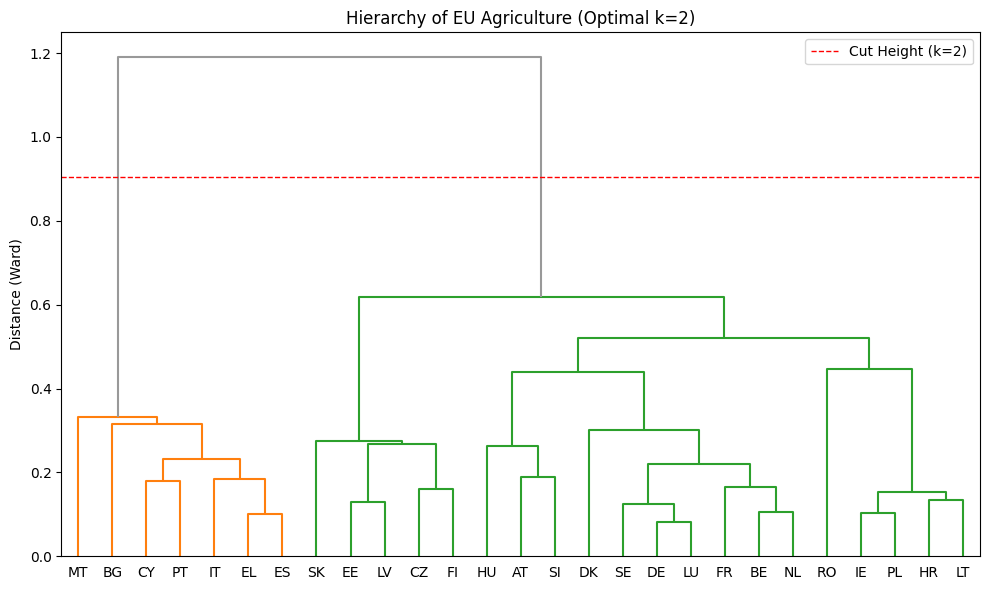

Generating Scatter Grid...


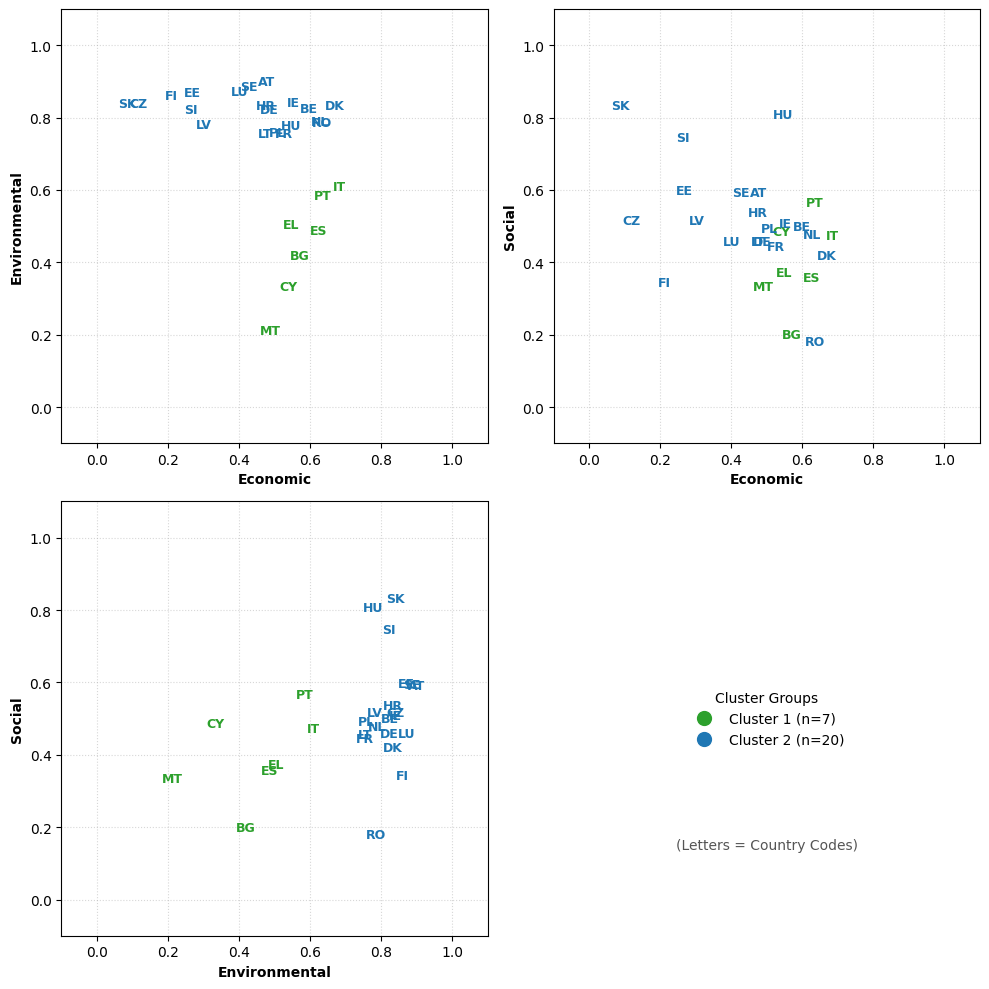

Generating Radar Profiles...


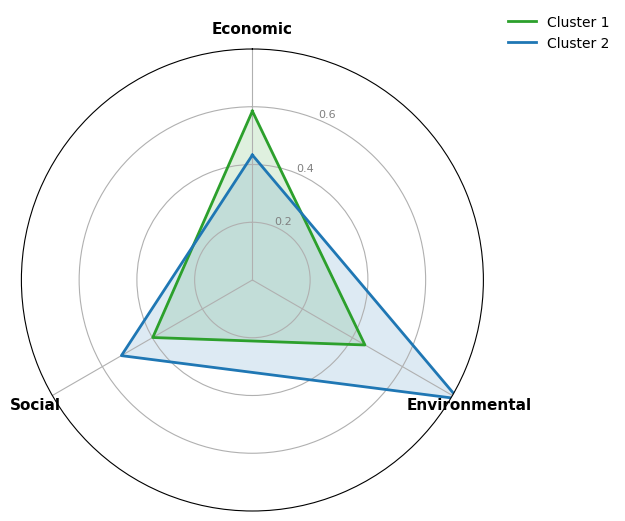

✓ Saved Assignments to: /content/Cluster_Assignments.csv


In [ ]:
# =========================================================
# HIERARCHICAL CLUSTERING - FINAL LINKED VERSION
# Context: Runs immediately after 'Entropy Pipeline'
# Inputs: Uses 'scores_wide' and 'results' from memory
# Output: Dendrogram, Text-Scatter, Radar, Excel/CSV exports
# =========================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering
from numpy.random import default_rng

# --------- CONFIG ----------
OUT = "/content/"
dims_order = ["Economic", "Environmental", "Social"]

# --- CUSTOM COLOR MAPPING (STRICT) ---
# 1. Green (#2ca02c) -> Cluster 1 (Leaders)
# 2. Blue  (#1f77b4) -> Cluster 2 (Laggards/Different Profile)
# 3. Orange (#ff7f0e) -> Cluster 3
CLUSTER_COLORS = ["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728", "#9467bd"]

# ---------- HELPERS ----------
def _country_code(s: str) -> str:
    """Extracts 'AT' from '(AT) Austria' or returns first 2 letters."""
    s = str(s)
    match = re.search(r'\(([A-Z]{2})\)', s)
    if match:
        return match.group(1)
    return s[:2].upper()

def _within_ss(X: np.ndarray, labels: np.ndarray) -> float:
    """Calculates Within-Cluster Sum of Squares (WCSS)."""
    ssw = 0.0
    for lab in np.unique(labels):
        Xi = X[labels == lab]
        if Xi.shape[0] <= 1: continue
        mu = Xi.mean(axis=0, keepdims=True)
        ssw += ((Xi - mu) ** 2).sum()
    return float(ssw)

def _gap_statistic(X: np.ndarray, k_list, B=10, seed=42) -> tuple:
    """Computes Gap Statistic to scientifically determine optimal k."""
    rng = default_rng(seed)
    n, d = X.shape
    mins, maxs = X.min(axis=0), X.max(axis=0)
    gaps, sks = {}, {}

    for k in k_list:
        try:
            # 1. Cluster original data
            model = AgglomerativeClustering(n_clusters=k, linkage="ward")
            labels = model.fit_predict(X)
            wk = _within_ss(X, labels)

            # 2. Cluster B random reference datasets
            log_wkbs = []
            for _ in range(B):
                Xb = rng.random((n, d)) * (maxs - mins)[None, :] + mins[None, :]
                lbl_b = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(Xb)
                wkb = _within_ss(Xb, lbl_b)
                if wkb > 0: log_wkbs.append(np.log(wkb))

            # 3. Stats
            lbar = np.mean(log_wkbs)
            s = np.std(log_wkbs, ddof=1)
            sk = s * np.sqrt(1 + 1.0/len(log_wkbs))

            gaps[k] = lbar - np.log(wk)
            sks[k] = sk
        except Exception as e:
            gaps[k], sks[k] = -np.inf, 0
    return gaps, sks

def _threshold_for_k(Z: np.ndarray, k: int) -> float:
    """Calculates where to cut the dendrogram tree."""
    heights = np.sort(Z[:, 2])
    n_merges = len(heights)
    if k <= 1: return heights.max() + 0.1
    idx = n_merges - k
    return 0.5 * (heights[idx] + heights[min(idx + 1, n_merges - 1)])

# ---------- 1) DATA PREPARATION (LINKING TO PREVIOUS STEP) ----------
print("Checking for previous pipeline data...")

# robust check: Ensure we have data to work with
if 'scores_wide' not in locals() and 'scores_wide' not in globals():
    # Only generates dummy data if you run this standalone (safety net)
    print("WARNING: 'scores_wide' not found. Generating MOCK DATA for testing.")
    dummy_countries = [f"Country_{i}" for i in range(1, 21)]
    scores_wide = pd.DataFrame(np.random.rand(20, 3), columns=[c + " Score" for c in dims_order])
    scores_wide["COUNTRY"] = dummy_countries
else:
    print("✓ Found 'scores_wide' from previous step.")

# Construct Weighted Matrix (Xw) using the 'results' dict if available
# This clusters based on Weighted Contribution, which is more accurate than raw scores.
Xw_parts = []
used_method = "Raw Scores"

for dim in dims_order:
    # Check if we have the granular weight data
    if "results" in locals() and dim in results:
        df_norm = results[dim].get("norm01", pd.DataFrame())
        series_w = results[dim].get("weights", pd.Series())

        # Match columns
        common = [c for c in df_norm.columns if c in series_w.index]
        if common:
            weighted = df_norm[common] * series_w[common]
            Xw_parts.append(weighted)
            used_method = "Weighted Features (High Precision)"
        else:
            Xw_parts.append(scores_wide[[dim + " Score"]])
    else:
        Xw_parts.append(scores_wide[[dim + " Score"]])

print(f"✓ Clustering Method: {used_method}")

Xw = pd.concat(Xw_parts, axis=1)
Xw.index = scores_wide["COUNTRY"]
X = Xw.values

# ---------- 2) CLUSTERING EXECUTION ----------
print("Running Ward's Hierarchical Clustering...")
Z = linkage(X, method="ward")

# Gap Statistic to find k
k_range = range(2, min(8, X.shape[0])) # Test k=2 to k=7
gaps, sks = _gap_statistic(X, k_range)

# Optimal k Selection (1-Standard-Error Rule)
k_opt = k_range[0]
for k in k_range[:-1]:
    # if gap(k) >= gap(k+1) - s(k+1)
    if gaps[k] >= (gaps[k+1] - sks[k+1]):
        k_opt = k
        break
print(f"✓ Optimal Clusters identified: k={k_opt}")

# Force k=2 if Gap stat is indecisive (common in small datasets)
if k_opt < 2: k_opt = 2

# Assign Labels
cluster_labels = fcluster(Z, k_opt, criterion='maxclust')
df_final = scores_wide.copy()
df_final["Cluster"] = cluster_labels
df_final["Code"] = df_final["COUNTRY"].apply(_country_code)

# ---------- 3) PLOT: DENDROGRAM ----------
print("Generating Dendrogram...")
dendro_labels = [_country_code(c) for c in Xw.index]
cut_height = _threshold_for_k(Z, k_opt)

plt.figure(figsize=(10, 6))
dendrogram(
    Z,
    labels=dendro_labels,
    leaf_rotation=0,
    leaf_font_size=10,
    color_threshold=cut_height,
    above_threshold_color="#999999"
)
plt.axhline(cut_height, c="r", ls="--", lw=1, label=f"Cut Height (k={k_opt})")
plt.ylabel("Distance (Ward)")
plt.title(f"Hierarchy of EU Agriculture (Optimal k={k_opt})", fontsize=12)
plt.legend()
plt.tight_layout()
dendro_path = os.path.join(OUT, f"Dendrogram_Ward_k{k_opt}.jpg")
plt.savefig(dendro_path, dpi=300)
plt.show()

# ---------- 4) PLOT: SCATTER GRID (TEXT MARKERS) ----------
print("Generating Scatter Grid...")
pairs = [
    ("Economic Score", "Environmental Score"),
    ("Economic Score", "Social Score"),
    ("Environmental Score", "Social Score")
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axs = axes.flatten()

cluster_counts = df_final["Cluster"].value_counts().to_dict()
sorted_clusters = sorted(df_final["Cluster"].unique())

for i, (xc, yc) in enumerate(pairs):
    ax = axs[i]
    for idx, row in df_final.iterrows():
        clust = row["Cluster"]
        # Sync Color: Cluster 1->Green, Cluster 2->Blue
        c_idx = (clust - 1) % len(CLUSTER_COLORS)
        color = CLUSTER_COLORS[c_idx]

        ax.text(
            row[xc], row[yc],
            row["Code"],
            color=color,
            fontsize=9,
            fontweight="bold",
            ha="center",
            va="center"
        )

    ax.set_xlabel(xc.replace(" Score", ""), fontweight="bold")
    ax.set_ylabel(yc.replace(" Score", ""), fontweight="bold")
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True, linestyle=":", alpha=0.5)

# Legend (Quadrant 4)
axs[3].axis("off")
legend_handles = []
for c in sorted_clusters:
    c_idx = (c - 1) % len(CLUSTER_COLORS)
    count = cluster_counts.get(c, 0)
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=CLUSTER_COLORS[c_idx],
               markersize=12,
               label=f'Cluster {c} (n={count})')
    )

axs[3].legend(handles=legend_handles, loc='center', title="Cluster Groups", frameon=False)
axs[3].text(0.5, 0.2, "(Letters = Country Codes)", ha='center', color="#555", transform=axs[3].transAxes)

plt.tight_layout()
scatter_path = os.path.join(OUT, f"Scatter_Clusters_k{k_opt}.jpg")
plt.savefig(scatter_path, dpi=300)
plt.show()

# ---------- 5) PLOT: RADAR PROFILES ----------
print("Generating Radar Profiles...")
profiles = df_final.groupby("Cluster")[["Economic Score", "Environmental Score", "Social Score"]].mean()

labels = ["Economic", "Environmental", "Social"]
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the loop

fig_radar, ax_radar = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for clust in sorted_clusters:
    values = profiles.loc[clust].values.flatten().tolist()
    values += values[:1]

    c_idx = (clust - 1) % len(CLUSTER_COLORS)
    color = CLUSTER_COLORS[c_idx]

    ax_radar.plot(angles, values, linewidth=2, linestyle='solid', label=f"Cluster {clust}", color=color)
    ax_radar.fill(angles, values, color=color, alpha=0.15)

ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(labels, fontweight='bold', fontsize=11)
ax_radar.set_ylim(0, 0.8) # Adjusted for typical normalized ranges
ax_radar.set_yticks([0.2, 0.4, 0.6])
ax_radar.set_yticklabels(["0.2", "0.4", "0.6"], color="grey", size=8)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), frameon=False)
radar_path = os.path.join(OUT, f"Radar_Clusters_k{k_opt}.jpg")
plt.savefig(radar_path, dpi=300, bbox_inches="tight")
plt.show()

# ---------- 6) EXPORTS ----------
out_csv = os.path.join(OUT, "Cluster_Assignments.csv")
df_final[["COUNTRY", "Cluster", "Economic Score", "Environmental Score", "Social Score"]].to_csv(out_csv, index=False)
print(f"✓ Saved Assignments to: {out_csv}")

Generating Gap Statistic Plot (Figure 6)...


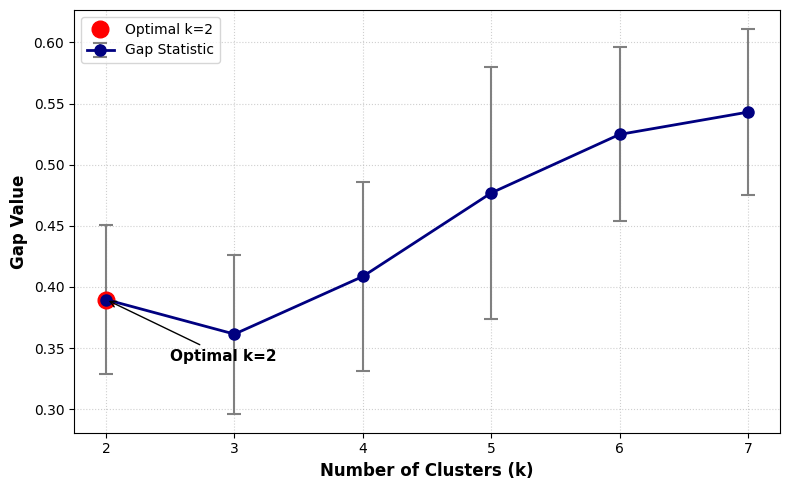

Gap Statistic plot saved to: /content/Gap_Statistic_Plot.jpg


In [ ]:
# ---------- PLOT: GAP STATISTIC (FIGURE 6) ----------
print("Generating Gap Statistic Plot (Figure 6)...")

# Convert dictionaries to lists for plotting
ks = list(gaps.keys())
gap_vals = [gaps[k] for k in ks]
errs = [sks[k] for k in ks]

fig_gap, ax_gap = plt.subplots(figsize=(8, 5))

# Plot Error Bars
ax_gap.errorbar(
    ks, gap_vals, yerr=errs,
    fmt='-o', color='navy', ecolor='gray',
    capsize=5, capthick=1.5, elinewidth=1.5,
    markersize=8, linewidth=2, label="Gap Statistic"
)

# Highlight Optimal k
opt_gap = gaps[k_opt]
ax_gap.plot(k_opt, opt_gap, 'ro', markersize=12, label=f"Optimal k={k_opt}")
ax_gap.annotate(
    f"Optimal k={k_opt}",
    (k_opt, opt_gap),
    xytext=(k_opt + 0.5, opt_gap - 0.05),
    arrowprops=dict(arrowstyle="->", color='black'),
    fontsize=11, fontweight='bold'
)

# Formatting
ax_gap.set_xlabel("Number of Clusters (k)", fontsize=12, fontweight='bold')
ax_gap.set_ylabel("Gap Value", fontsize=12, fontweight='bold')
# ax_gap.set_title("Gap Statistic Validation", fontsize=14, fontweight='bold')
ax_gap.grid(True, linestyle=":", alpha=0.6)
ax_gap.legend(fontsize=10)

# Save and Show
gap_plot_path = os.path.join(OUT, "Gap_Statistic_Plot.jpg")
plt.tight_layout()
plt.savefig(gap_plot_path, dpi=300)
plt.show()

print(f"Gap Statistic plot saved to: {gap_plot_path}")

In [ ]:
# Code for downloading all files
!zip -r /content/farm_models_output.zip /content/

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2026.01.16/ (stored 0%)
  adding: content/.config/logs/2026.01.16/14.24.28.646070.log (deflated 57%)
  adding: content/.config/logs/2026.01.16/14.24.18.954466.log (deflated 58%)
  adding: content/.config/logs/2026.01.16/14.23.31.981136.log (deflated 92%)
  adding: content/.config/logs/2026.01.16/14.24.29.392089.log (deflated 56%)
  adding: content/.config/logs/2026.01.16/14.24.13.071214.log (deflated 87%)
  adding: content/.config/logs/2026.01.16/14.24.03.314209.log (deflated 58%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/configurations/ (store